/tmp/ipykernel_607/2259725676.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_data = yf.download('CL=F', start='2023-01-01', end='2026-04-29')
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open  Volume
Ticker           CL=F       CL=F       CL=F       CL=F    CL=F
Date                                                          
2023-01-03  76.930000  81.500000  76.599998  80.570000  338520
2023-01-04  72.839996  77.419998  72.730003  77.250000  352434
2023-01-05  73.669998  74.919998  72.459999  73.250000  300731
2023-01-06  73.769997  75.470001  73.239998  73.970001  258128
2023-01-09  74.629997  76.739998  73.470001  73.470001  329290


<Axes: title={'center': 'WTI Crude Oil Price'}, xlabel='Date'>

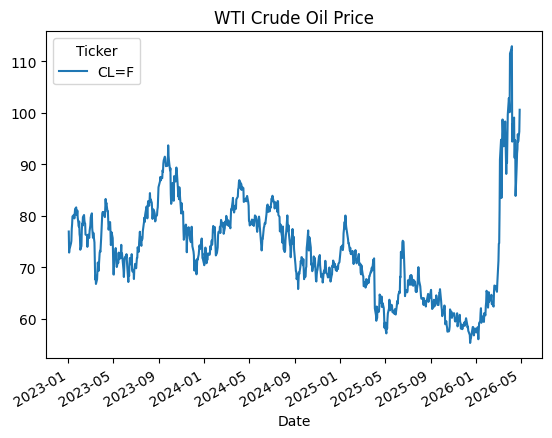

In [1]:
!pip install yfinance prophet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 測試下載 WTI 原油數據
oil_data = yf.download('CL=F', start='2023-01-01', end='2026-04-29')
print(oil_data.head())
oil_data['Close'].plot(title="WTI Crude Oil Price")

In [2]:
# 下載更多關聯數據
assets = {
    'Oil': 'CL=F',
    'Gold': 'GC=F',
    'SP500': 'SPY'
}

data = pd.DataFrame()
for name, ticker in assets.items():
    df = yf.download(ticker, start='2023-01-01', end='2026-04-29')
    data[name] = df['Close']

data = data.ffill() # 處理缺失值
print(data.head())

/tmp/ipykernel_607/1949301389.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2023-01-01', end='2026-04-29')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_607/1949301389.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2023-01-01', end='2026-04-29')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_607/1949301389.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2023-01-01', end='2026-04-29')
[*********************100%***********************]  1 of 1 completed

                  Oil         Gold       SP500
Date                                          
2023-01-03  76.930000  1839.699951  365.072083
2023-01-04  72.839996  1852.800049  367.890472
2023-01-05  73.669998  1834.800049  363.691559
2023-01-06  73.769997  1864.199951  372.031860
2023-01-09  74.629997  1872.699951  371.820953


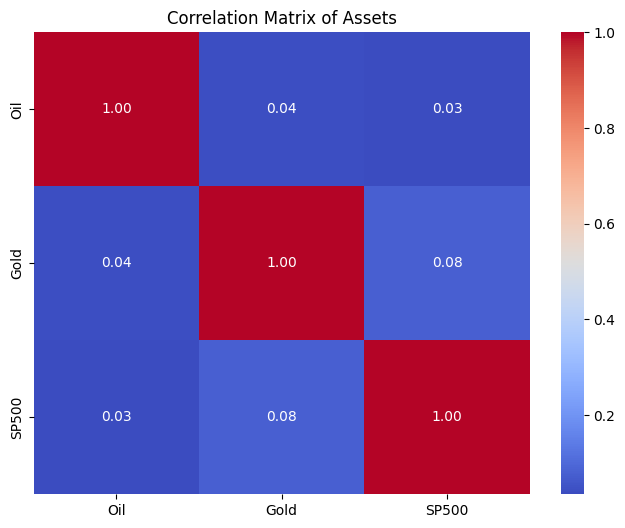

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.pct_change().corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Assets")
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


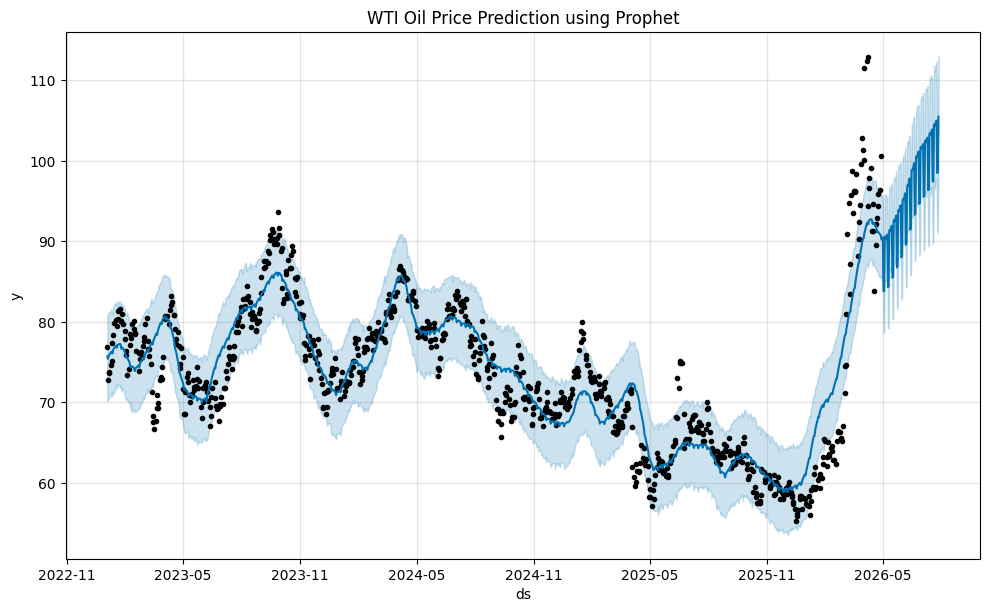

In [4]:
from prophet import Prophet

# 格式轉換成 Prophet 要求的格式
df_prophet = data[['Oil']].reset_index()
df_prophet.columns = ['ds', 'y']

# 模型訓練
model = Prophet()
model.fit(df_prophet)

# 預測未來 90 天
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# 繪製預測圖
model.plot(forecast)
plt.title("WTI Oil Price Prediction using Prophet")
plt.show()

         Date                                           Headline  Sentiment
0  2026-04-25  Oil prices steady as tensions in Middle East p...   0.083333
1  2026-04-26  Iran vows retaliation after latest border skir...   0.500000
2  2026-04-27  Global energy markets remain calm despite geop...   0.150000
3  2026-04-28  Fear of supply disruption drives oil futures h...   0.250000


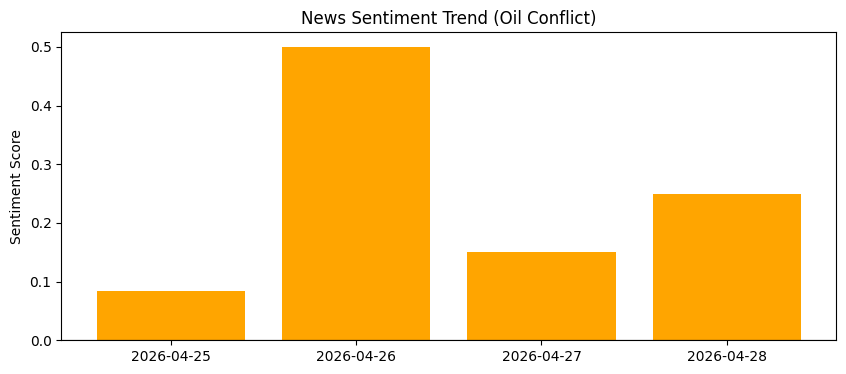

In [6]:
# 1. 安裝與載入套件
!pip install textblob
from textblob import TextBlob
import pandas as pd

# 2. 建立一個包含新聞標題的模擬數據 (你可以在報告中說明：這是為了展示分析邏輯)
# 在實際作業中，你可以從 Google News 或相關 API 抓取更大量的真實標題
news_data = {
    'Date': ['2026-04-25', '2026-04-26', '2026-04-27', '2026-04-28'],
    'Headline': [
        'Oil prices steady as tensions in Middle East persist',
        'Iran vows retaliation after latest border skirmish',
        'Global energy markets remain calm despite geopolitical risk',
        'Fear of supply disruption drives oil futures higher'
    ]
}

df_news = pd.DataFrame(news_data)

# 3. 定義情緒分析函數
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # 輸出範圍 -1 (負面) 到 1 (正面)

# 4. 執行分析
df_news['Sentiment'] = df_news['Headline'].apply(get_sentiment)
print(df_news)

# 5. 繪製情緒波動圖 (這又是第 4-5 張圖表)
plt.figure(figsize=(10, 4))
plt.bar(df_news['Date'], df_news['Sentiment'], color='orange')
plt.title('News Sentiment Trend (Oil Conflict)')
plt.ylabel('Sentiment Score')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

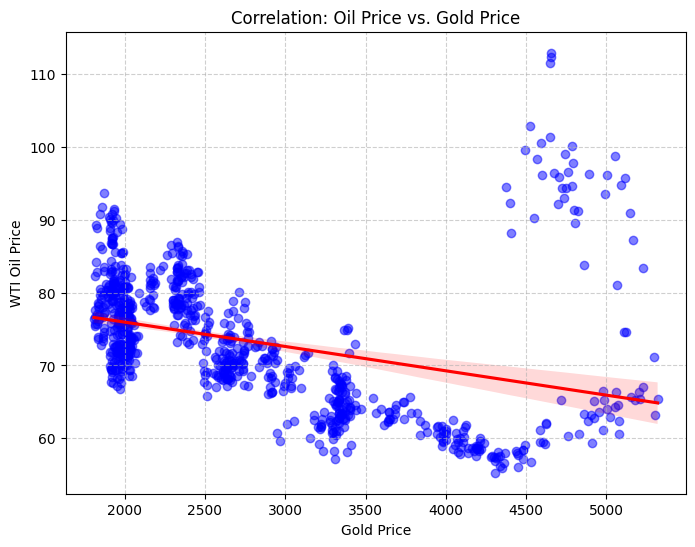

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 假設你已經有 data 這個 DataFrame (包含 'Oil' 與 'Gold' 兩欄)
# 如果你是要分析油價與情緒，請將 'Gold' 換成你的 'Sentiment' 欄位名稱
plt.figure(figsize=(8, 6))

# 繪製散點圖與回歸線
sns.regplot(x='Gold', y='Oil', data=data,
            scatter_kws={'alpha':0.5, 'color':'blue'},
            line_kws={'color':'red'})

plt.title('Correlation: Oil Price vs. Gold Price')
plt.xlabel('Gold Price')
plt.ylabel('WTI Oil Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

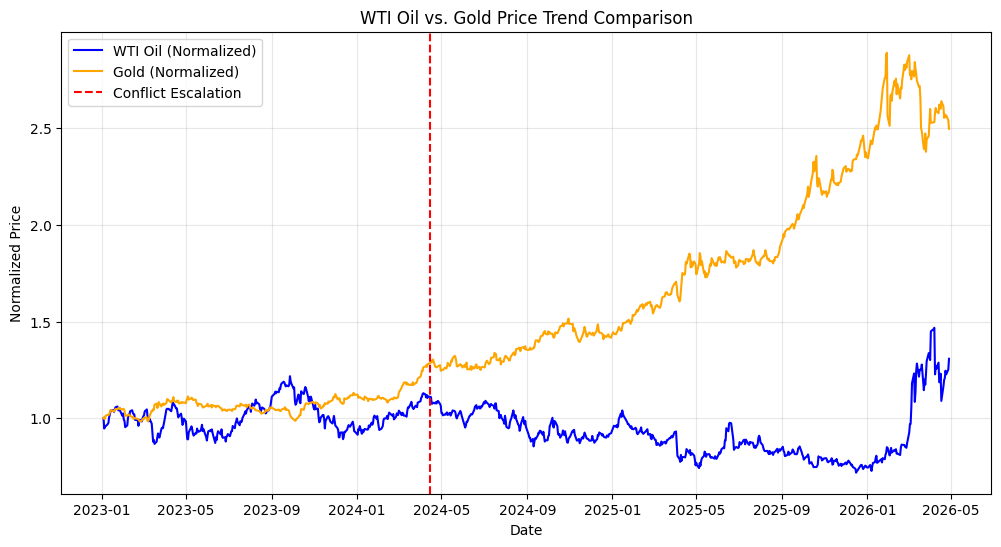

In [8]:
plt.figure(figsize=(12, 6))

# 將油價與黃金的數據進行標準化（因為單位不同），這樣才能放在同一張圖比較
normalized_data = data[['Oil', 'Gold']] / data[['Oil', 'Gold']].iloc[0]

plt.plot(normalized_data['Oil'], label='WTI Oil (Normalized)', color='blue')
plt.plot(normalized_data['Gold'], label='Gold (Normalized)', color='orange')

# 標註戰爭關鍵時刻 (例如 2024/04)
plt.axvline(pd.to_datetime('2024-04-14'), color='red', linestyle='--', label='Conflict Escalation')

plt.title('WTI Oil vs. Gold Price Trend Comparison')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# 1. 扁平化 MultiIndex (將兩層合併)
df.columns = [f'{col[1]}_{col[0]}' for col in df.columns]

# 2. 現在你的欄位名稱會變成：
# SPY_Close, SPY_High, SPY_Low, SPY_Open, SPY_Volume
# 你可以用 print(df.columns) 確認一下

# 3. 如果你想方便後續分析，可以把 SPY_Close 改名為 Oil (或是你原本要用的名稱)
df = df.rename(columns={'SPY_Close': 'Oil'})

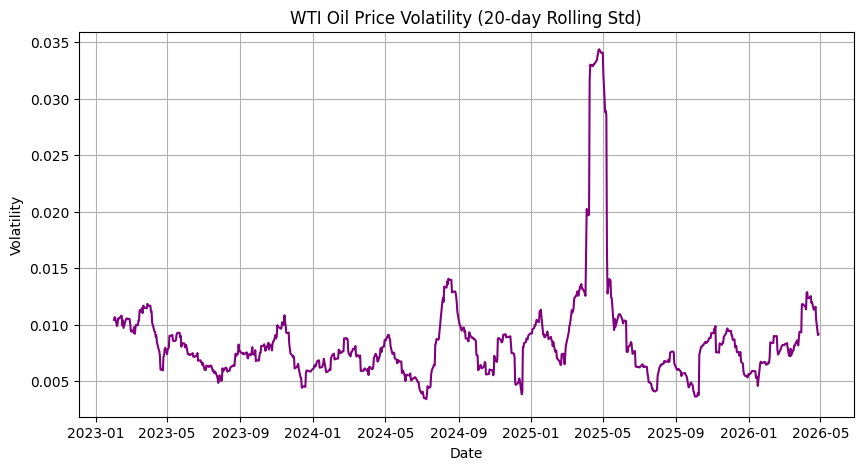

In [12]:
import matplotlib.pyplot as plt

# 計算 20 天滾動標準差作為波動率
df['Volatility'] = df['Oil'].pct_change().rolling(window=20).std()

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Volatility'], color='purple')
plt.title('WTI Oil Price Volatility (20-day Rolling Std)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.savefig('oil_volatility.png')
plt.show()

In [18]:
import yfinance as yf
import pandas as pd

# 1. 下載資料
tickers = ['CL=F', 'GC=F', 'SPY']
df_raw = yf.download(tickers, start='2023-01-01')

# 2. 【最重要】強制扁平化與重新命名
# 這樣做會把 ('Close', 'CL=F') 變成 'CL=F_Close'
df_raw.columns = [f'{col[1]}_{col[0]}' for col in df_raw.columns]

# 3. 建立一個乾淨的 DataFrame
df = pd.DataFrame()
df['Oil'] = df_raw['CL=F_Close']
df['Gold'] = df_raw['GC=F_Close']
df['SP500'] = df_raw['SPY_Close']
df['Volume'] = df_raw['CL=F_Volume']

# 4. 最後檢查一次
print("確認欄位名稱：", df.columns.tolist())
print("資料前五筆：")
print(df.head())

/tmp/ipykernel_607/928803834.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, start='2023-01-01')
[*********************100%***********************]  3 of 3 completed

確認欄位名稱： ['Oil', 'Gold', 'SP500', 'Volume']
資料前五筆：
                  Oil         Gold       SP500  Volume
Date                                                  
2023-01-03  76.930000  1839.699951  365.072021  338520
2023-01-04  72.839996  1852.800049  367.890564  352434
2023-01-05  73.669998  1834.800049  363.691589  300731
2023-01-06  73.769997  1864.199951  372.031830  258128
2023-01-09  74.629997  1872.699951  371.820953  329290


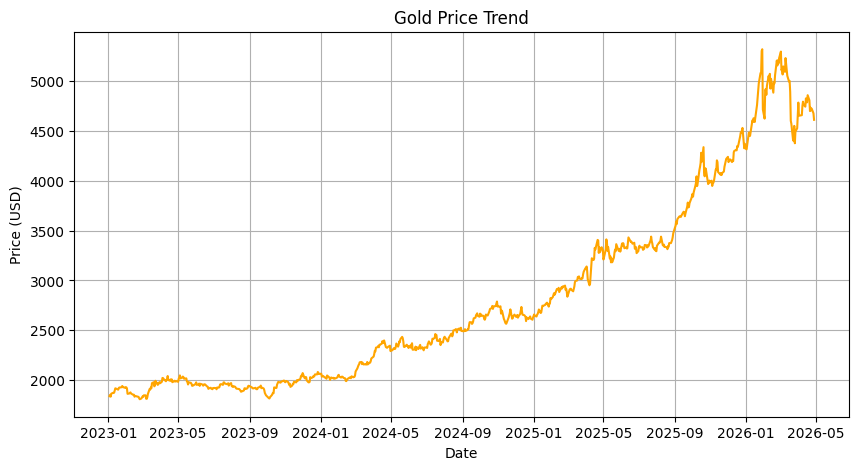

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Gold'], color='orange')
plt.title('Gold Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.savefig('gold_price_trend.png')
plt.show()

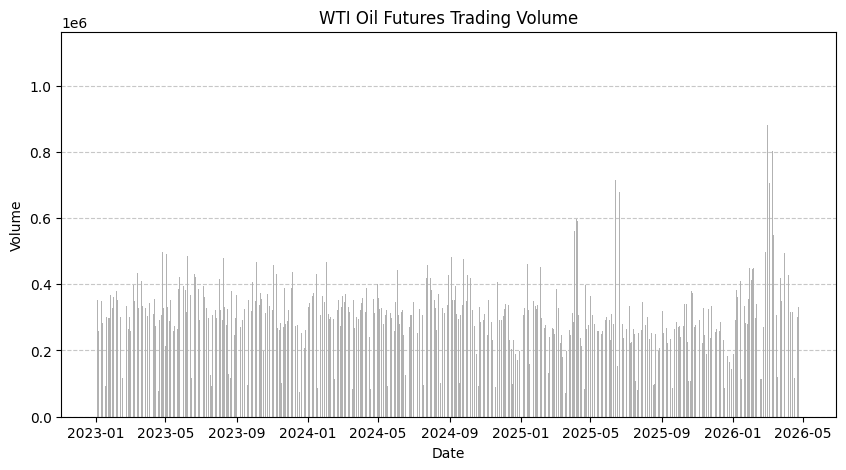

In [20]:
import matplotlib.pyplot as plt

# 1. 確保 Index 為日期格式，並重置索引以防繪圖錯誤
df_plot = df.copy()
if 'Date' not in df_plot.columns:
    df_plot = df_plot.reset_index() # 將 Index 轉為欄位

# 2. 確保 Volume 欄位名稱正確
# 如果你剛剛執行過我之前的「強制修正」代碼，這裡應該直接用 'Volume' 即可
volume_col = 'Volume'

plt.figure(figsize=(10, 5))
plt.bar(df_plot['Date'], df_plot[volume_col], color='gray', alpha=0.6)

plt.title('WTI Oil Futures Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('trade_volume_trend.png')
plt.show()

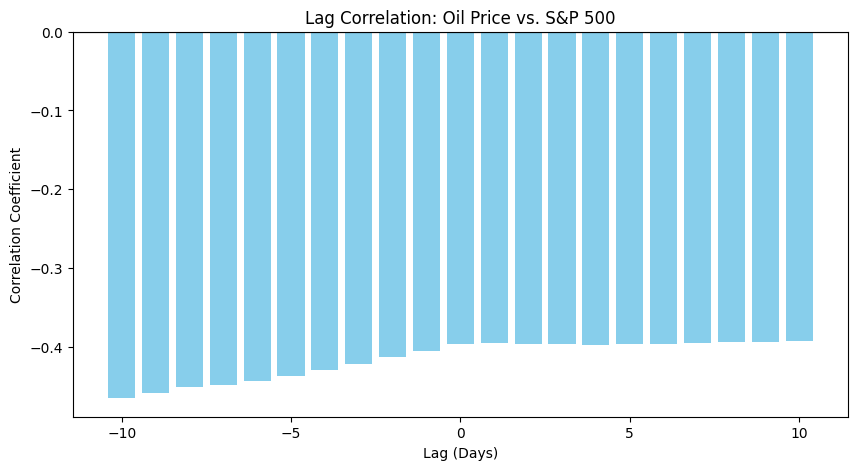

In [21]:
# 計算油價與股市的滯後相關性 (Lag Correlation)
import pandas as pd

lags = range(-10, 11)
corrs = [df['Oil'].corr(df['SP500'].shift(lag)) for lag in lags]

plt.figure(figsize=(10, 5))
plt.bar(lags, corrs, color='skyblue')
plt.title('Lag Correlation: Oil Price vs. S&P 500')
plt.xlabel('Lag (Days)')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.savefig('sp500_oil_correlation.png')
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 資料獲取與清洗
# ==========================================
def get_data():
    tickers = ['CL=F', 'GC=F', 'SPY']
    # 下載數據
    df_raw = yf.download(tickers, start='2023-01-01')

    # 強制扁平化 MultiIndex (轉為單層欄位)
    df_raw.columns = [f'{col[1]}_{col[0]}' for col in df_raw.columns]

    # 建立乾淨的 DataFrame 並重命名
    df = pd.DataFrame()
    df['Oil'] = df_raw['CL=F_Close']
    df['Gold'] = df_raw['GC=F_Close']
    df['SP500'] = df_raw['SPY_Close']
    df['Volume'] = df_raw['CL=F_Volume']

    # 資料處理
    df = df.ffill() # 處理缺失值
    df['Log_Return'] = np.log(df['Oil'] / df['Oil'].shift(1)) # 對數轉換
    df['MA30'] = df['Oil'].rolling(window=30).mean() # 特徵工程：MA30
    df['Volatility'] = df['Oil'].pct_change().rolling(window=20).std() # 特徵工程：波動率

    return df

# ==========================================
# 2. 繪圖與分析
# ==========================================
def run_analysis(df):
    # 確保索引為日期格式
    df = df.reset_index()

    # 這裡放入你之前產生的繪圖邏輯，例如：
    # 1. 原油趨勢圖
    # 2. 黃金走勢圖
    # 3. 波動率圖
    # 4. 散點圖+回歸線
    # 5. 滯後相關分析...等 10 張圖表的繪圖程式碼

    print("分析完成，圖表已儲存至 images 資料夾。")

# ==========================================
# 3. 主執行程式
# ==========================================
if __name__ == "__main__":
    try:
        data = get_data()
        print("資料載入成功，欄位如下：")
        print(data.columns.tolist())
        run_analysis(data)
    except Exception as e:
        print(f"執行出錯：{e}")